# Coupling normalization across every proof class

We attempt to match a declared generator-level coupling strength **before** computing SPIs. The primary comparison is the raw mean of each MPI, $m$, versus SPI–SPI, $z$. This covers every historical proof class plus the distinct newer VAR conditions: 16 conditions, 24 recordings each, with $M=16$ and $T=1000$. No subset is selected to favour a representation.

**Scope of the claim.** The matched quantity is the total local response to cross-channel perturbations per native update. This is not a coordinate-free or universal measure of physical coupling, and it need not equal observed dependence strength. Noise controls necessarily retain zero coupling. We report that distinction rather than turn independent noise into a different coupled process.

In [1]:
from pathlib import Path
import sys,json
ROOT=Path.cwd().resolve()
while not (ROOT/'pyproject.toml').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
if str(ROOT) not in sys.path:sys.path.insert(0,str(ROOT))
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display
from scripts.calibrate_all_proof_coupling import OUT
from scripts.analyze_all_proof_coupling import rows as load_rows
from scripts import analyze_native_coupling as study
rows=load_rows()
display(pd.read_csv(OUT/'class-inventory.csv'))

,source,original,normalized
0,historical14,var-phi-0.95_cpl-0.4,VAR-legacy-0.95-0.4
1,historical14,var-phi-0.2_cpl-0.4,VAR-legacy-0.2-0.4
2,historical14,var-phi-0.2_cpl-0.8,VAR-legacy-0.2-0.8
3,historical14,kuramoto_omega-fast,Kuramoto-fast
4,historical14,kuramoto_omega-slow,Kuramoto-slow
5,historical14,cauchy-noise,Cauchy-noise
6,historical14,gaussian-noise,Gaussian-noise
7,historical14,wave-1d,Wave
8,historical14,defect-turbulence,CML-1.895
9,historical14,sti-i,CML-1.7522


## What was normalized?

For a native update $x_{t+1}=F(x_t)$, define

$$G=\frac{1}{MT}\sum_{t,i}\sum_{j\ne i}\left|\frac{\partial F_i}{\partial x_j}(x_t)\right|.$$

Each off-diagonal row sum bounds the first-order incoming response to a unit-bounded perturbation of the other state coordinates; G averages this local sensitivity over receivers and recorded states.

The target $G=0.20\pm0.002$ is inherited from the native VAR/CML pilot as an explicit experimental operating point, not an established universal strength scale. It is feasible for all coupled variants tested. The target was chosen before the MPI outcomes. Each recording is centered channelwise and divided by one common empirical RMS channel SD; this removes arbitrary overall amplitude without applying per-MPI normalization.

**VAR.** With $F_i=\phi x_i+(g/2)(x_{i-1}+x_{i+1})$, $G=g$. We set $g=.2$. The historical generator rescaled its nominal coefficients to spectral radius .98; we preserve the resulting self coefficients .532, .196 and .108889. The newer self coefficients .2 and .7 remain literal. Two newer VAR classes differ only in coupling and become the same generator after matching; they are merged. In particular, self=.196 and self=.2 are intentionally retained near-duplicates, so their distinguishability should not be presumed.

**Quadratic CML.** For $f_\alpha(x)=1-\alpha x^2$ and nearest-neighbour diffusive mixing, $G=g\alpha\langle|x_{i-1}|+|x_{i+1}|\rangle$. We calibrate g per realization for all six alpha values: 1.45, 1.69, 1.7522, 1.85, 1.895 and 2. The physical lattice has 100 sites, with a 16-site observation crop; both physical neighbours of each observed site enter G, including boundary neighbours outside the crop. Historical regime names identify provenance only: changing coupling can change the regime.

**Kuramoto.** We retain negative coupling, both native frequency distributions and $\Delta t=.00625$. The degree-normalized phase update has $G=|K|\Delta t\langle\sum_{j\ne i}|\cos(\theta_j-\theta_i)|/(M-1)\rangle$. We calibrate $|K|$ and observe $\sin\theta$, as in the proof. This is **latent phase gain**, not the Jacobian in sine-observation coordinates. The much larger magnitude of K changes the dynamical operating point.

**Wave.** We hold the historical timestep .00125 fixed and change wave speed from 10 to $10\sqrt{2.5}\approx15.8114$. The ordinary two-step displacement update has total off-site derivative $G=2(c\Delta t/\Delta x)^2=.2$. Its Courant number is $\sqrt{.1}<1$; the zero-velocity initialization step is an exception to the ordinary recurrence. Merely changing c under the original adaptive timestep would leave the MTS unchanged. This derivative describes the latent displacement update; the original observation noise SD=.01 is retained. The native wave records begin at their random initial condition; VAR, CML and Kuramoto use 2,000 burn-in updates.

**Gaussian and Cauchy noise.** Both remain independent, $G=0$, and are explicitly null controls. Cauchy variance does not exist at population level; its scale normalization uses the finite sample only.

These equations follow the actual repository implementations. For background on the dependence of oscillator dynamics on coupling and frequency heterogeneity, see [Acebrón et al. (2005)](https://doi.org/10.1103/RevModPhys.77.137); for the wave recurrence and Courant restriction, see [Strang's wave-equation notes](https://ocw.mit.edu/courses/18-086-mathematical-methods-for-engineers-ii-spring-2006/8eaa23367474c809cc0816f24fdacc7f_am53.pdf). Neither reference establishes the cross-family gain convention used here; that is our explicit experimental choice.

,n,gain_min,gain_max,parameter_min,parameter_max
label,,,,,
CML-1.45,24,0.1982,0.2018,0.1250,0.1344
CML-1.69,24,0.1982,0.2019,0.1172,0.1312
CML-1.7522,24,0.1981,0.2019,0.1156,0.1250
CML-1.85,24,0.1980,0.2018,0.1115,0.1156
CML-1.895,24,0.1982,0.2018,0.1062,0.1094
CML-2,24,0.1990,0.2000,0.0938,0.0938
Cauchy-noise,24,0.0000,0.0000,0.0000,0.0000
Gaussian-noise,24,0.0000,0.0000,0.0000,0.0000
Kuramoto-fast,24,0.1983,0.2020,48.7500,51.2500


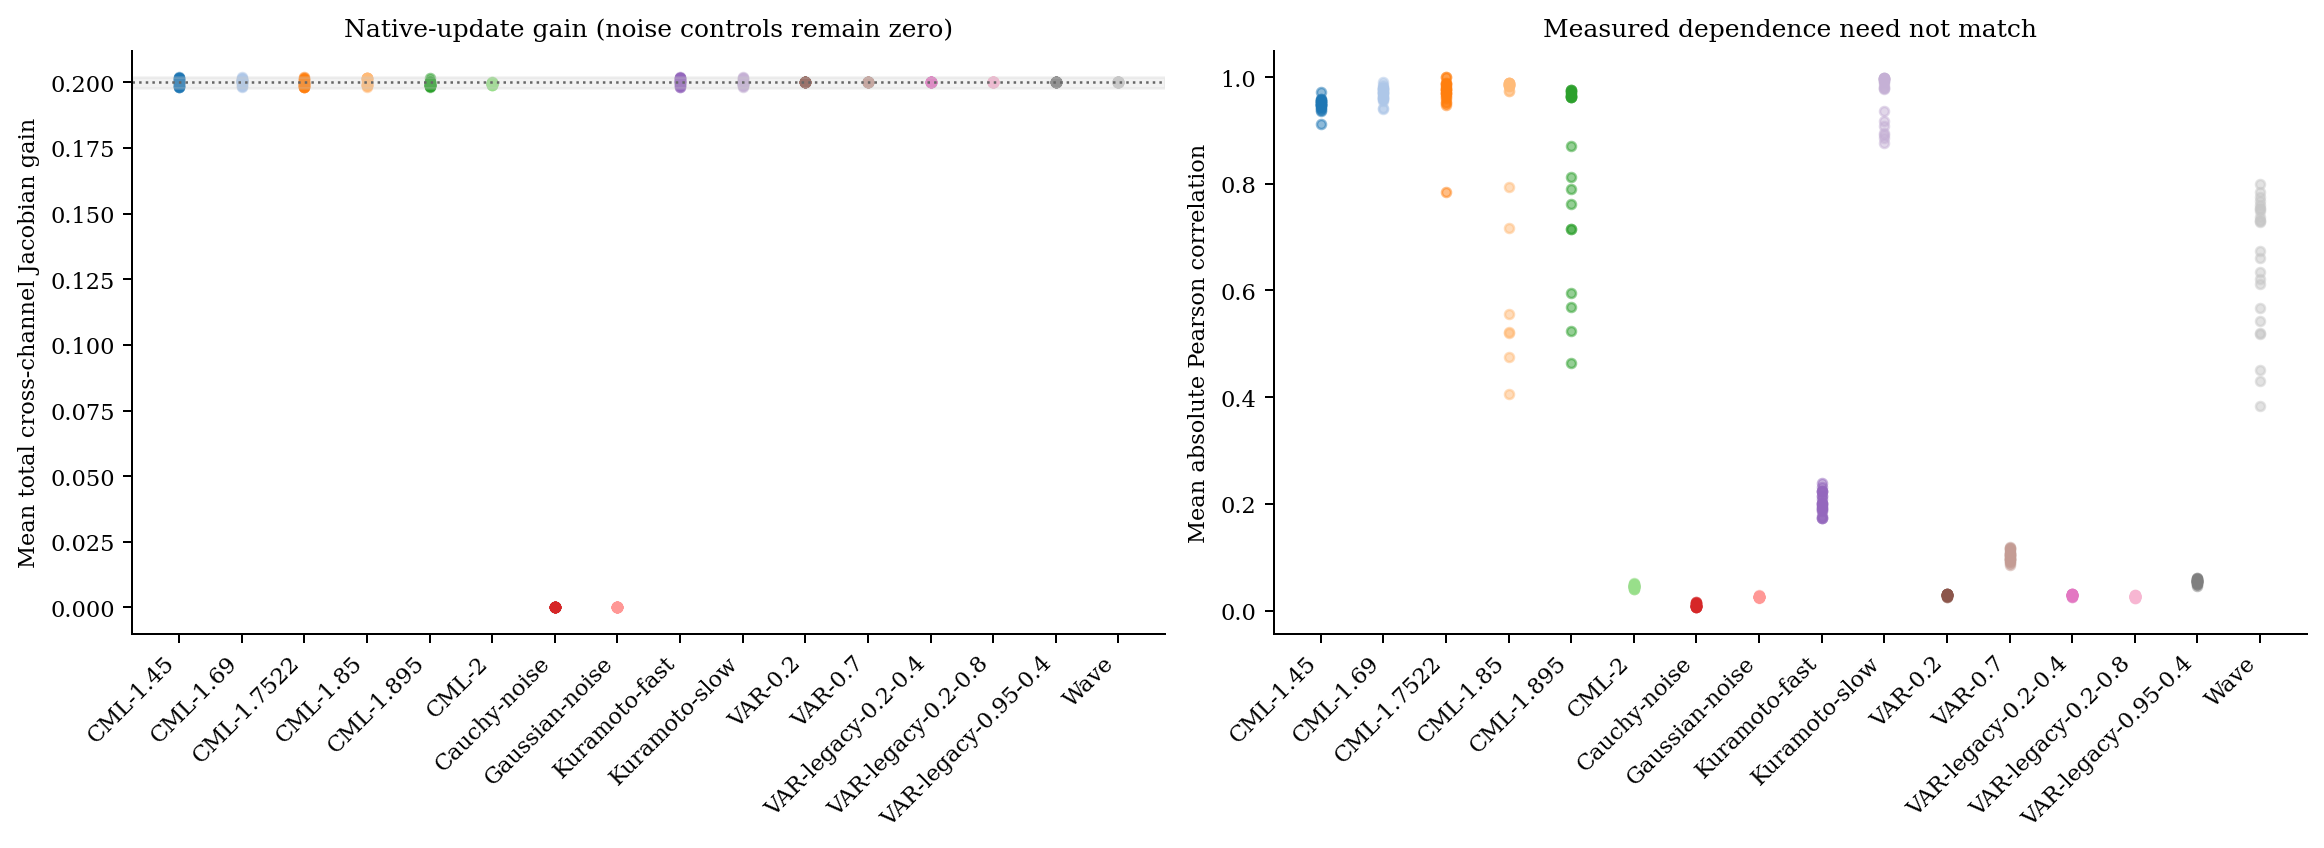

In [2]:
display(rows.groupby('label').agg(n=('row_id','size'),gain_min=('strength','min'),gain_max=('strength','max'),parameter_min=('g','min'),parameter_max=('g','max')).round(4))
fig=study.plot_calibration(rows,OUT)
plt.show()

## Held-recording comparison

**Result.** Across all 16 conditions, held balanced accuracy is **89.6% for both MPI means and SPI–SPI**, versus 6.25% chance. Means without PCA reach **90.6%**. The paired z-minus-mean difference is 0 percentage points (conditional held-block bootstrap 95% interval −3.65 to +3.65 points). Within the six CML variants, means reach 94.4%, z 95.8%, and means without PCA 95.8%. The historical 14-class panel gives 92.9%, 94.6% and 94.6%, respectively. Every reported paired z-minus-mean or z-minus-full-mean interval includes zero.

This normalization therefore **does not establish the intended separation or an advantage over the mean baseline**. Mean SPI responses retain substantial class information at equal declared gain; they are not exclusively strength descriptors. Keeping all classes exposes this result rather than selecting a favourable subset.

Development uses paired seed blocks 0–11; evaluation uses blocks 12–23. Preprocessing is fitted only on development: 95% feature-validity selection, median imputation, SD scaling, clipping at ±5 SD, and PCA with at most 20 components. A fixed logistic classifier ($C=1$) predicts held recordings. The sensitivity with **all selected mean features and no PCA** prevents an arbitrary PCA bottleneck from being mistaken for missing marginal information. Distributions are secondary (mean, SD, and five quantiles).

PCA and UMAP are fitted on development data and transform held recordings. All figures are boxed and square; colours are consistent. Embedding appearance is descriptive, not evidence that one representation contains no class information. Four declared scopes are retained: all 16 conditions, historical 14, the 14 coupled conditions excluding noise, and all six CML variants. Preprocessing is shared across the full development bank; each scope's classifier and two-dimensional display are fitted using its development rows.

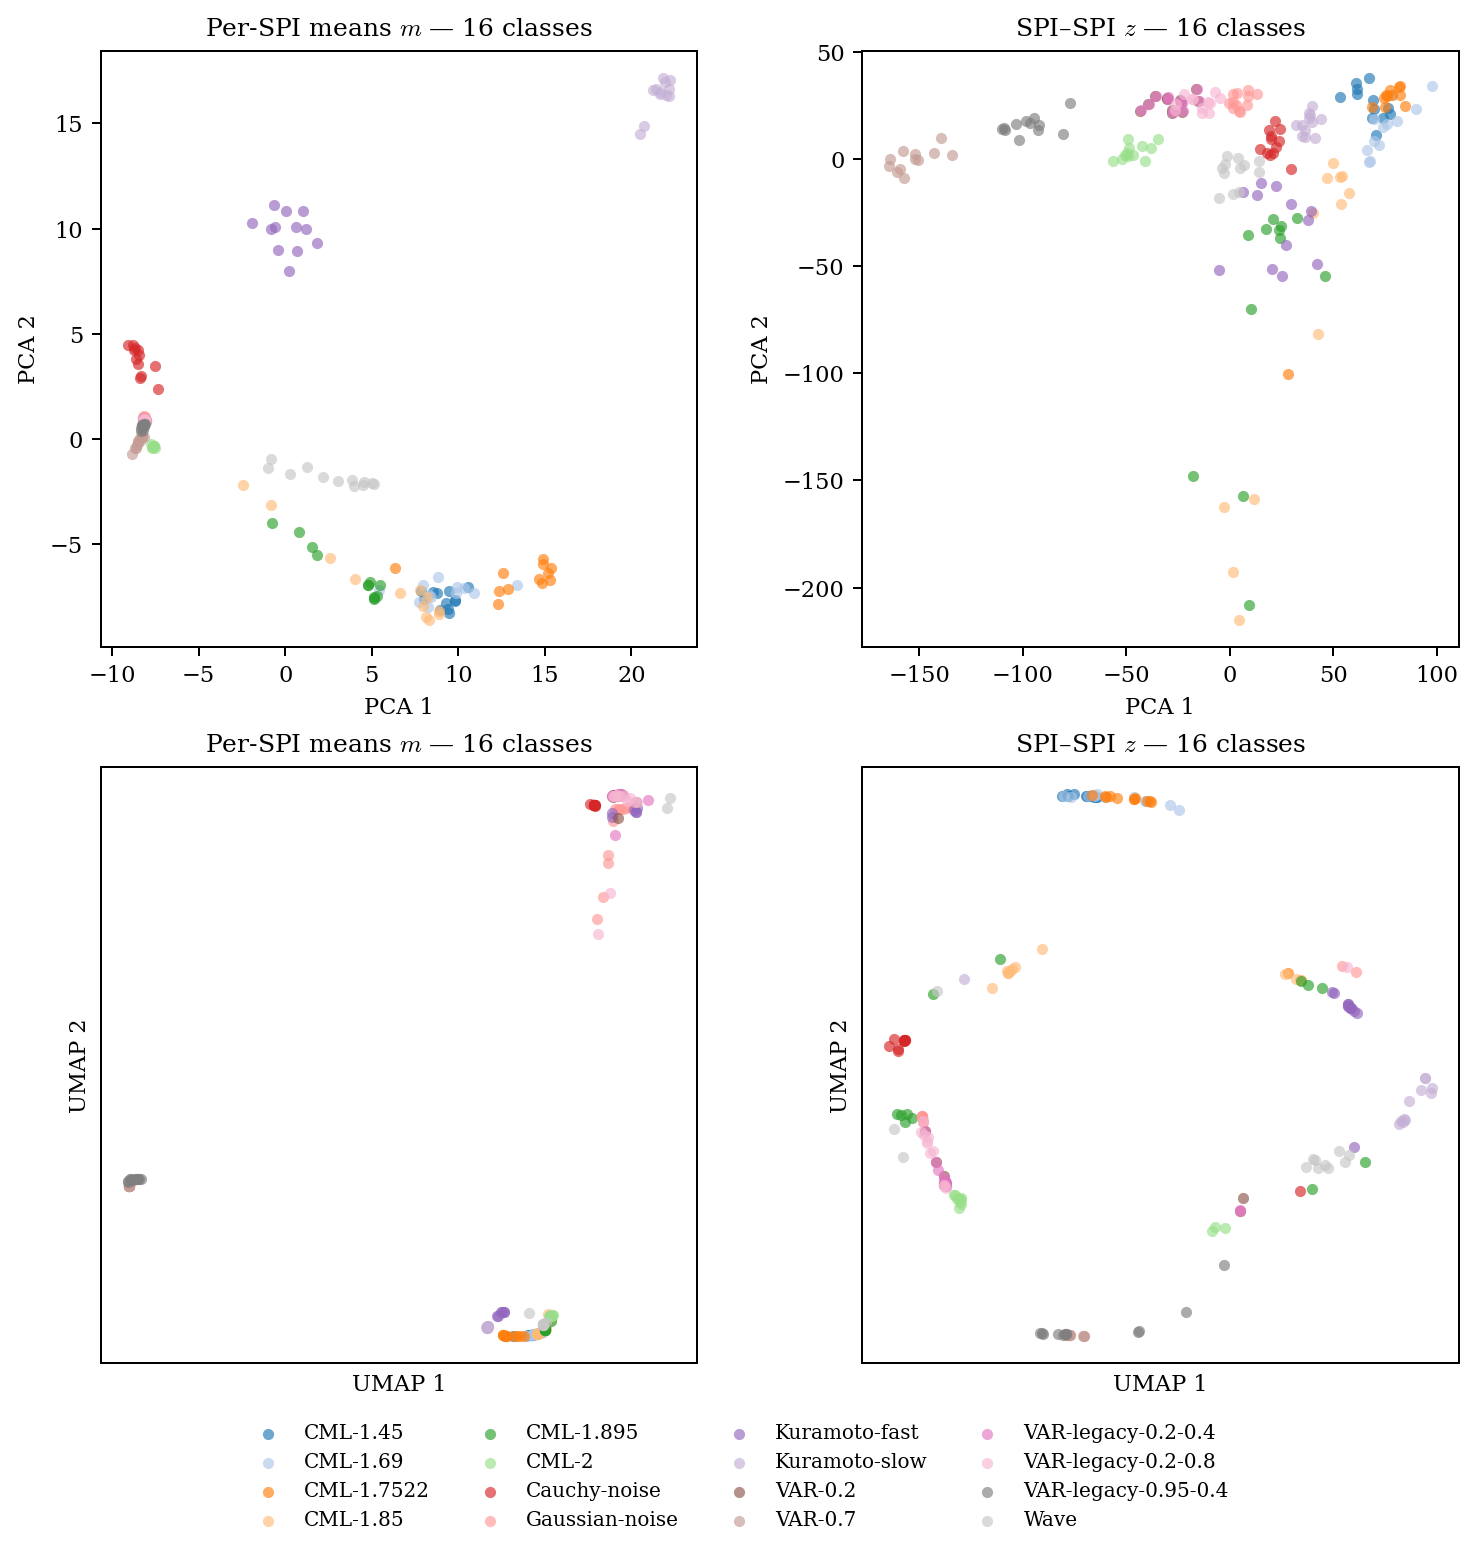

In [3]:
fig=study.plot_embedding('all16',rows,OUT)
plt.show()

In [4]:
metrics=pd.read_csv(OUT/'metrics.csv')
primary=metrics[metrics.method.isin(['mean','mean_without_PCA','z'])]
display(primary.round(3))
display(pd.read_csv(OUT/'paired.csv').query("comparison != 'z - distribution'").round(3))

,method,scope,n,balanced_accuracy,low,high,chance
0,mean,all16,192,0.896,0.865,0.927,0.062
1,mean,CML6,72,0.944,0.875,1.000,0.167
2,mean,historical14,168,0.929,0.893,0.958,0.071
3,mean,coupled14,168,0.899,0.869,0.923,0.071
8,z,all16,192,0.896,0.865,0.922,0.062
9,z,CML6,72,0.958,0.917,1.000,0.167
10,z,historical14,168,0.946,0.911,0.976,0.071
11,z,coupled14,168,0.893,0.857,0.923,0.071
28,mean_without_PCA,all16,192,0.906,0.891,0.922,0.062
29,mean_without_PCA,CML6,72,0.958,0.917,1.000,0.167


,scope,comparison,difference,low,high
0,all16,z - mean,0.000,-0.036,0.036
1,all16,z - mean_without_PCA,-0.010,-0.036,0.016
3,CML6,z - mean,0.014,-0.028,0.056
4,CML6,z - mean_without_PCA,0.000,-0.042,0.042
6,historical14,z - mean,0.018,-0.024,0.060
7,historical14,z - mean_without_PCA,0.000,-0.030,0.030
9,coupled14,z - mean,-0.006,-0.042,0.024
10,coupled14,z - mean_without_PCA,0.000,-0.024,0.024


## All six CML variants

These share the local map family and lattice construction, but varying alpha and retuning coupling can substantially change their dynamics. This is a within-family check, not confirmation that the original six regime labels survive normalization.

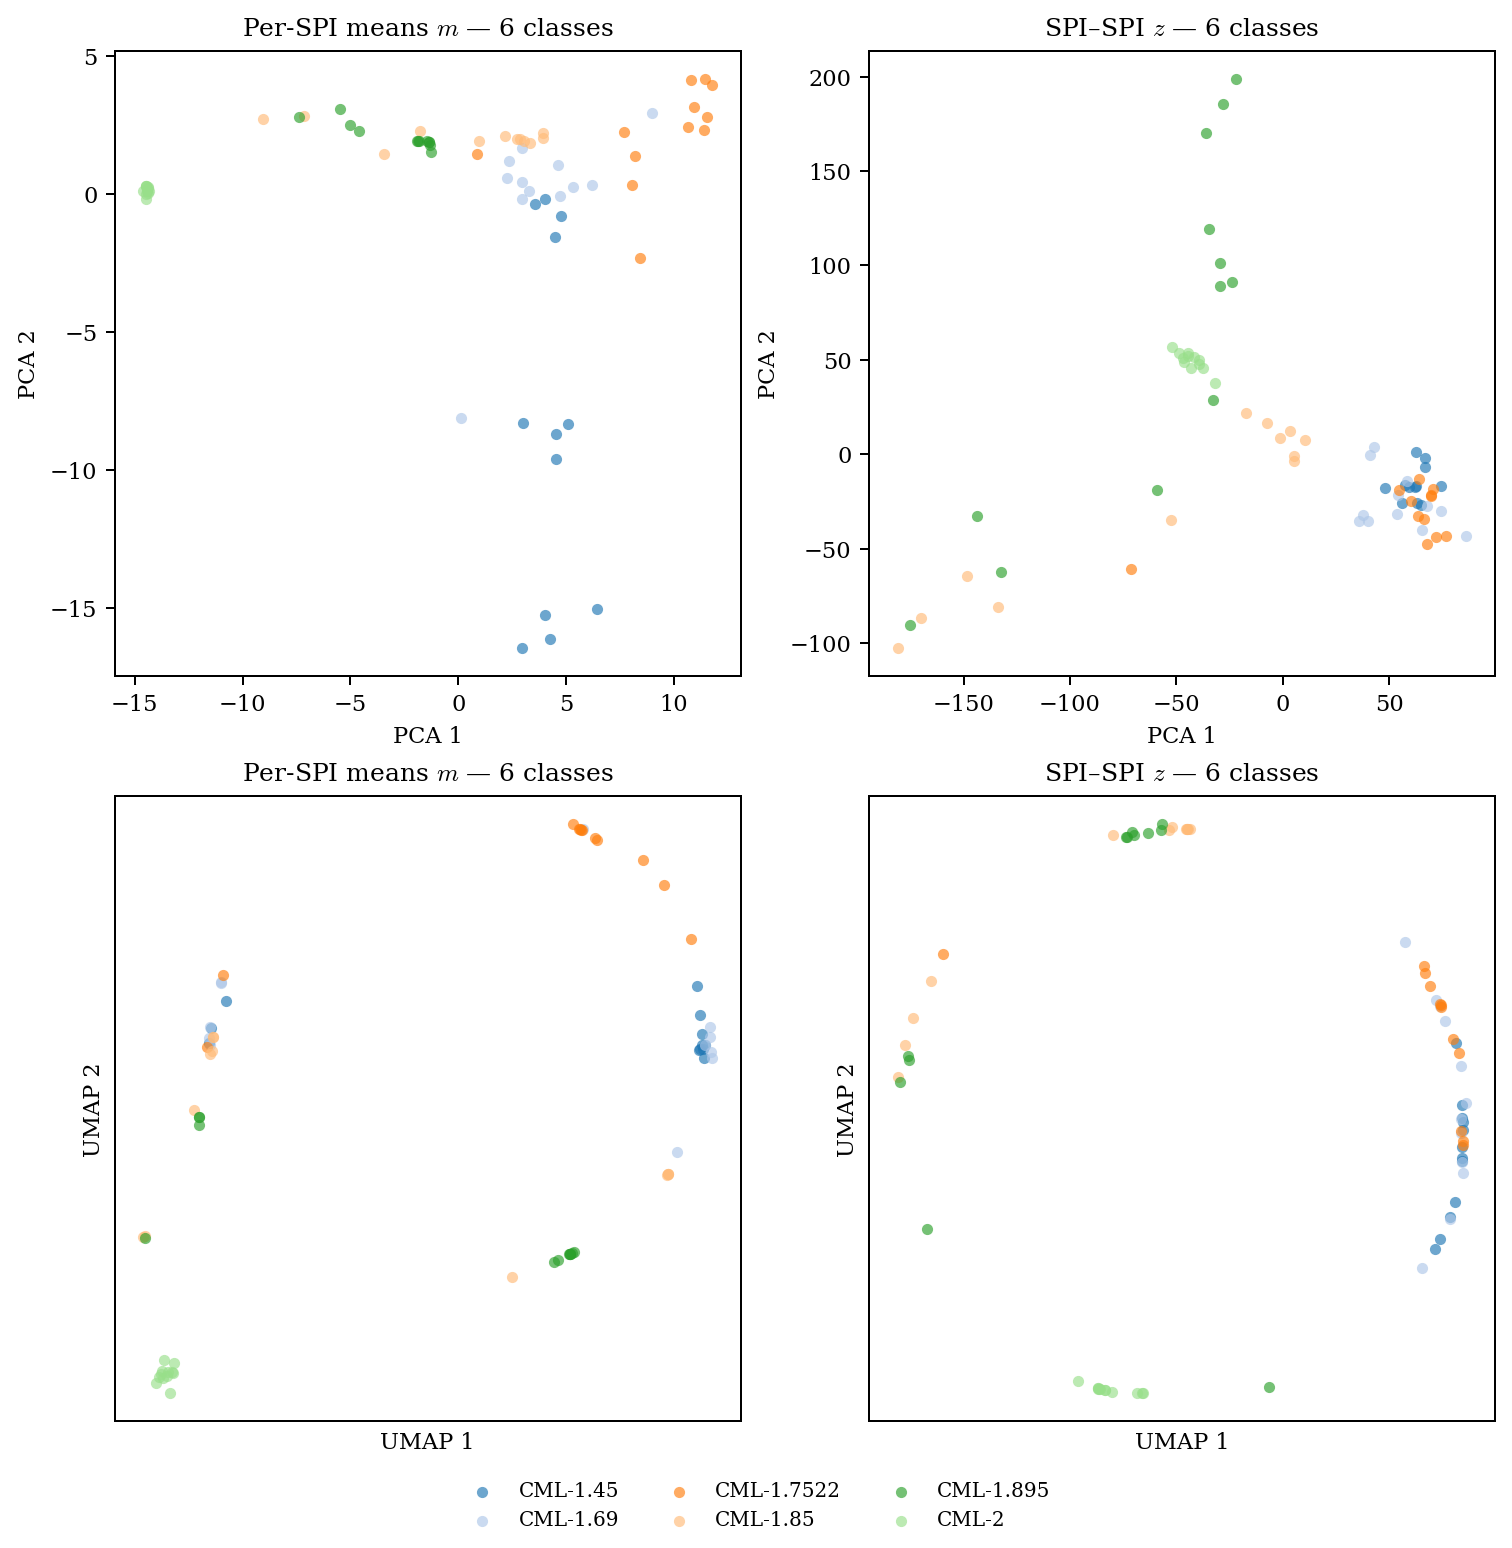

In [5]:
fig=study.plot_embedding('CML6',rows,OUT)
plt.show()

## Where any gain comes from

Per-class held accuracy reveals whether an aggregate advantage reflects a broad improvement or a small number of variants. The independent noise classes are shown but do not support a positive-strength-matched claim. Near-identical normalized VAR variants remain in the comparison. The exact z-validity mask alone reaches 56.25% overall, and perfectly classifies both Kuramoto variants and Gaussian noise in this held panel. Thus successful family separation can partly reflect which estimators are defined; it is not by itself evidence about the numerical SPI–SPI geometry.

In [6]:
per=pd.read_csv(OUT/'per-class.csv')
display(per.query("scope=='all16'")[['label','mean','mean_without_PCA','z','z_validity']].round(3))
display(metrics[metrics.scope.isin(['all16','CML6']) & metrics.method.isin(['distribution','validity','profile_validity','z_validity','strength_only'])].round(3))

,label,mean,mean_without_PCA,z,z_validity
6,CML-1.45,0.917,1.000,1.000,0.583
7,CML-1.69,0.917,0.917,1.000,0.333
8,CML-1.7522,0.833,0.833,0.917,0.750
9,CML-1.85,1.000,0.917,0.917,0.500
10,CML-1.895,1.000,1.000,0.917,0.833
11,CML-2,1.000,1.000,1.000,0.500
12,Cauchy-noise,1.000,1.000,1.000,0.917
13,Gaussian-noise,1.000,1.000,1.000,1.000
14,Kuramoto-fast,1.000,1.000,1.000,1.000
15,Kuramoto-slow,1.000,1.000,1.000,1.000


,method,scope,n,balanced_accuracy,low,high,chance
4,distribution,all16,192,0.891,0.875,0.906,0.062
5,distribution,CML6,72,0.958,0.917,1.000,0.167
12,validity,all16,192,0.406,0.365,0.443,0.062
13,validity,CML6,72,0.625,0.528,0.708,0.167
16,profile_validity,all16,192,0.589,0.547,0.620,0.062
17,profile_validity,CML6,72,0.708,0.597,0.806,0.167
20,z_validity,all16,192,0.562,0.516,0.604,0.062
21,z_validity,CML6,72,0.694,0.611,0.778,0.167
24,strength_only,all16,192,0.156,0.130,0.182,0.062
25,strength_only,CML6,72,0.250,0.167,0.306,0.167


## Interpretation and limitations

A successful calibration establishes equal G under the stated native-coordinate/update conventions, **not equal marginal MPI statistics**. Strong classification by means would therefore be a negative result for the proposed picture of unstructured marginals versus structured SPI–SPI under this normalization. A positive paired gain for z would show added utility for this readout and experiment, not generic strength invariance or absence of information in means. The two near-identical VAR variants also make perfect classification an inappropriate success criterion.

Bootstrap intervals resample the 12 held seed blocks, preserving all classes within each draw; paired intervals use the same blocks. They condition on trained models and omit training uncertainty. These are exploratory results with a small number of independent realizations, not a final benchmark. Three z-validity-only classifier fits reached the original 3,000-iteration cap; increasing that cap to 20,000 resolved convergence without changing the model, regularization, data split or primary results. All 32 final fits converged. The controls are diagnostics under this readout, not exhaustive removal of shortcuts. The profile-validity control adds one bit per SPI indicating a finite, nonconstant edge profile; it therefore captures the missingness pattern of z. A second control uses the full binary z-validity mask, matching the dimension and preprocessing of z without its values. These diagnostics were added after the initial pilot and before the expanded results, without changing the primary readout. Undefined statistics remain missing; validity-only and residual-G-only controls expose possible shortcuts. The 95% validity rule may exclude statistics disproportionately unavailable for particular classes; the audit table records retained features and held missingness.

In [7]:
display(pd.DataFrame(json.loads((OUT/'analysis.json').read_text())['diagnostics']).T.round(3))
optimizer=pd.read_csv(OUT/'optimizer.csv')
assert optimizer.converged.all()
display(optimizer[optimizer.retried])

,features,components,held_max_selected_missing_fraction,held_mean_selected_missing_fraction,explained_variance
mean,226.0,20.0,0.133,0.002,0.982
distribution,1627.0,20.0,0.129,0.002,0.963
z,20704.0,20.0,0.280,0.010,0.775
validity,89.0,20.0,0.000,0.000,0.996
profile_validity,147.0,20.0,0.000,0.000,0.962
z_validity,31434.0,20.0,0.000,0.000,0.958
strength_only,1.0,1.0,0.000,0.000,1.000


,method,scope,iterations,iteration_cap,retried,converged
20,z_validity,all16,5356,20000,True,True
22,z_validity,historical14,4794,20000,True,True
23,z_validity,coupled14,4339,20000,True,True


Reproduction uses `configs/analysis/proof-strength-all-261003.yaml`, `scripts/calibrate_all_proof_coupling.py`, and the two external corpus configurations `native-gain-261003.yaml` and `proof-strength-all-261003.yaml`. The combined manifest binds the two immutable raw archives; extraction checks source/member hashes, the exact 289-SPI catalogue and serial estimator RNG policy. `python -m scripts.analyze_native_coupling extract`, then `python -m scripts.analyze_all_proof_coupling extract` and `analyze` reconstruct the comparison. Figures are generated here from cached numeric outputs; no pyspi computation is required to rerender this notebook.